In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

**LOADING DATASET**

In [51]:
df = pd.read_csv(r'/Users/user/Documents/Data Analysis Projects/E-Commerce Analysis/data.csv', encoding="ISO-8859-1")

**DATA INSPECTION**

In [52]:
print("First 5 rows:")
print(df.head())
print( "-" * 70)

print("Data Info:")
print(df.info())
print( "-" * 70)

print("Descriptive Statistics:")
print(df.describe(include= 'object'))
print( "-" * 70)

print(f"Dataset Shape: {df.shape}")
print(f"Columns name: {list(df.columns)}")

First 5 rows:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
----------------------------------------------------------------------
Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Co

**Data Quality**

In [53]:
print("Columns Data type:")
print(df.dtypes)
print( "-" * 70)

df['InvoiceDate']= pd.to_datetime(df['InvoiceDate'])
print(f"Date Range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Period: {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} days")
print( "-" * 70)

print(f"Unique Customers: {df['CustomerID'].nunique():,}")
print(f"Unique Products (StockCode): {df['StockCode'].nunique():,}")
print(f"Unique Invoices: {df['InvoiceNo'].nunique():,}")
print(f"Unique Countries: {df['Country'].nunique():,}")

Columns Data type:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object
----------------------------------------------------------------------
Date Range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Period: 373 days
----------------------------------------------------------------------
Unique Customers: 4,372
Unique Products (StockCode): 4,070
Unique Invoices: 25,900
Unique Countries: 38


**Missing Values Analysis**

In [54]:
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_nonzero = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("Missing Values Analysis:")
print(missing_nonzero)
if missing_data['Missing_Count'].sum() == 0:
    print("No missing values found")

print( "-" * 70)

# Impact: rows without CustomerID cannot be attributed to a specific customer
null_customer = df[df['CustomerID'].isnull()].shape[0]
print(f"Rows without CustomerID: {null_customer:,} ({null_customer/len(df)*100:.2f}%)")
print("Will be removed for customer analysis")

Missing Values Analysis:
                  Column  Missing_Count  Missing_Percentage
CustomerID    CustomerID         135080               24.93
Description  Description           1454                0.27
----------------------------------------------------------------------
Rows without CustomerID: 135,080 (24.93%)
Will be removed for customer analysis


**Duplicate Check**

In [55]:
full_duplicates = df.duplicated().sum()
print(f"Full Row Duplicates: {full_duplicates:,} ({full_duplicates/len(df)*100:.2f}%)")

transaction_cols = ['InvoiceNo', 'CustomerID', 'StockCode']
transaction_duplicates = df.duplicated(subset=transaction_cols).sum()
print(f"Transaction Duplicates: {transaction_duplicates:,} ({transaction_duplicates/len(df)*100:.2f}%)")

print("-" * 70)

cancelled = df[df['InvoiceNo'].str.startswith('C', na=False)].shape[0]
print(f"Cancelled Orders (InvoiceNo='C...'): {cancelled:,} ({cancelled/len(df)*100:.2f}%)")

Full Row Duplicates: 5,268 (0.97%)
Transaction Duplicates: 10,684 (1.97%)
----------------------------------------------------------------------
Cancelled Orders (InvoiceNo='C...'): 9,288 (1.71%)


**Outliers**

In [56]:
negative_qty = df[df['Quantity'] < 0].shape[0]
zero_qty = df[df['Quantity'] == 0].shape[0]
print(f"Negative Quantities (Returns): {negative_qty:,}")
print(f"Zero Quantities: {zero_qty:,}")
print(f"Quantity Range: {df['Quantity'].min()} to {df['Quantity'].max()}")

print("-" * 70)

print(f"Unit Price Range: {df['UnitPrice'].min():.2f} to {df['UnitPrice'].max():.2f}")
print(f"Negative Prices: {(df['UnitPrice'] < 0).sum():,}")
print(f"Zero Prices: {(df['UnitPrice'] == 0).sum():,}")

print("-" * 70)

df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
print(f"Total Amount Range: {df['TotalAmount'].min():.2f} to {df['TotalAmount'].max():.2f}")
print(f"Total Revenue: {df['TotalAmount'].sum():,.2f}")


Negative Quantities (Returns): 10,624
Zero Quantities: 0
Quantity Range: -80995 to 80995
----------------------------------------------------------------------
Unit Price Range: -11062.06 to 38970.00
Negative Prices: 2
Zero Prices: 2,515
----------------------------------------------------------------------
Total Amount Range: -168469.60 to 168469.60
Total Revenue: 9,747,747.93


**DATA CLEANING**

**Handling missing values**

In [57]:
total_rows = len(df)
print(f"Starting dataset: {total_rows:,} rows\n")

missing_customerid = df['CustomerID'].isna().sum()
missing_description = df['Description'].isna().sum()

print(f"Rows with missing CustomerID: {missing_customerid:,} ({missing_customerid / total_rows * 100:.2f}%)")
print(f"Rows with missing Description: {missing_description:,} ({missing_description / total_rows * 100:.2f}%)")

df_clean = df.dropna(subset=['CustomerID', 'Description']).copy()
removed_missing = total_rows - len(df_clean)

print("\nAction: Remove rows with missing CustomerID/Description")
print(f"Removed: {removed_missing:,} rows ({removed_missing / total_rows * 100:.2f}%)")
print(f"Remaining: {len(df_clean):,} rows")

print("=" * 80)
print(f"Original rows : {total_rows:,}")
print(f"Rows removed  : {removed_missing:,} (missing CustomerID/Description)")
print(f"Rows remaining: {len(df_clean):,} ({len(df_clean) / total_rows * 100:.1f}% retained)")

Starting dataset: 541,909 rows

Rows with missing CustomerID: 135,080 (24.93%)
Rows with missing Description: 1,454 (0.27%)

Action: Remove rows with missing CustomerID/Description
Removed: 135,080 rows (24.93%)
Remaining: 406,829 rows
Original rows : 541,909
Rows removed  : 135,080 (missing CustomerID/Description)
Rows remaining: 406,829 (75.1% retained)


In [58]:
rows_before_filters = len(df_clean)
print(f"New Starting rows: {rows_before_filters:,}\n")

n_duplicates = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().copy()
print(f"Removed duplicates: {n_duplicates:,} rows")

New Starting rows: 406,829

Removed duplicates: 5,225 rows


In [59]:
cancelled_order = df_clean['InvoiceNo'].astype(str).str.startswith('C', na=False)
n_cancelled = cancelled_order.sum()
df_clean = df_clean[~cancelled_order].copy()
print(f"Removed cancelled orders: {n_cancelled:,} rows")

Removed cancelled orders: 8,872 rows


In [60]:
unique_stock_codes = df_clean['StockCode'].astype(str).unique()
anomalous_stock_codes = [code for code in unique_stock_codes if sum(ch.isdigit() for ch in code) in (0, 1)]
stock_anomaly_mask = df_clean['StockCode'].astype(str).isin(anomalous_stock_codes)
n_stock_anomaly = stock_anomaly_mask.sum()
df_clean = df_clean[~stock_anomaly_mask].copy()
print(f"Removed StockCode anomalies: {n_stock_anomaly:,} rows")

Removed StockCode anomalies: 1,549 rows


In [68]:
nonpositive_price_mask = df_clean['UnitPrice'] <= 0
n_nonpositive_price = nonpositive_price_mask.sum()
df_clean = df_clean[~nonpositive_price_mask].copy()
print(f"Removed zero/non-positive UnitPrice: {n_nonpositive_price:,} rows\n")

nonpositive_qty_mask = df_clean['Quantity'] <= 0
n_nonpositive_qty = nonpositive_qty_mask.sum()
df_clean = df_clean[~nonpositive_qty_mask].copy()
print(f"Removed zero/non-positive Quantity: {n_nonpositive_qty:,} rows")

Removed zero/non-positive UnitPrice: 0 rows

Removed zero/non-positive Quantity: 0 rows


In [69]:
df_clean.reset_index(drop=True, inplace=True)

total_removed = n_duplicates + n_cancelled + n_stock_anomaly + n_nonpositive_price + n_nonpositive_qty
print("-" * 70)
print("SUMMARY")
print(f"Removed duplicates: {n_duplicates:,}\n")
print(f"Removed cancelled orders: {n_cancelled:,}\n")
print(f"Removed StockCode anomalies: {n_stock_anomaly:,}\n")
print(f"Removed zero/non-positive UnitPrice: {n_nonpositive_price:,}\n")
print(f"Removed zero/non-positive Quantity: {n_nonpositive_qty:,}\n")
print(f"Total removed: {total_removed:,} rows\n")
print(f"Rows after Clean {len(df_clean):,}")
print(f"Retention from original: {len(df_clean) / total_rows * 100:.1f}%")

----------------------------------------------------------------------
SUMMARY
Removed duplicates: 5,225

Removed cancelled orders: 8,872

Removed StockCode anomalies: 1,549

Removed zero/non-positive UnitPrice: 0

Removed zero/non-positive Quantity: 0

Total removed: 15,646 rows

Rows after Clean 391,150
Retention from original: 72.2%


In [65]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], errors='coerce')
invalid_dates = df_clean['InvoiceDate'].isna().sum()
if invalid_dates > 0:
    df_clean = df_clean[df_clean['InvoiceDate'].notna()].copy()

df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['Day'] = df_clean['InvoiceDate'].dt.day
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.dayofweek
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
df_clean['WeekOfYear'] = df_clean['InvoiceDate'].dt.isocalendar().week.astype(int)

df_clean['CustomerID'] = df_clean['CustomerID'].astype('int64')

print("Derived features created:")
print("- TotalAmount = Quantity × UnitPrice")
print("- InvoiceDate converted to datetime")
print("- Year, Month, Day, DayOfWeek, Hour, WeekOfYear")
if invalid_dates > 0:
    print(f"- Dropped rows with invalid InvoiceDate: {invalid_dates:,}")

print(f"\nDataset ready after Clean and Processing: {len(df_clean):,} rows × {df_clean.shape[1]} columns")

Derived features created:
- TotalAmount = Quantity × UnitPrice
- InvoiceDate converted to datetime
- Year, Month, Day, DayOfWeek, Hour, WeekOfYear

Dataset ready after Clean and Processing: 391,150 rows × 15 columns


**EXPLORATORY DATA ANALYSIS (EDA)**

**Business Metrics Overview**

In [71]:
print("-" * 70)
print("BUSINESS OVERVIEW METRICS")
print("-" * 70)

total_revenue = df_clean['TotalAmount'].sum()
total_line_items = len(df_clean)
total_orders = df_clean['InvoiceNo'].nunique()
unique_customers = df_clean['CustomerID'].nunique()
unique_products = df_clean['StockCode'].nunique()
unique_countries = df_clean['Country'].nunique()

print(f"\nTotal Revenue: £{total_revenue:,.2f}")
print(f"Total Line Items (rows): {total_line_items:,}")
print(f"Total Orders (unique InvoiceNo): {total_orders:,}")
print(f"Unique Customers: {unique_customers:,}")
print(f"Unique Products: {unique_products:,}")
print(f"Unique Countries: {unique_countries:,}")

print(f"\nKey Averages:")
print(f"   - Avg Order Value: £{total_revenue/total_orders:,.2f}")
print(f"   - Avg Customer Spend: £{total_revenue/unique_customers:,.2f}")
print(f"   - Orders per Customer: {total_orders/unique_customers:.2f}")

print(f"\nBasic metrics calculated")


----------------------------------------------------------------------
BUSINESS OVERVIEW METRICS
----------------------------------------------------------------------

Total Revenue: £8,737,227.64
Total Line Items (rows): 391,150
Total Orders (unique InvoiceNo): 18,402
Unique Customers: 4,334
Unique Products: 3,659
Unique Countries: 37

Key Averages:
   - Avg Order Value: £474.80
   - Avg Customer Spend: £2,015.97
   - Orders per Customer: 4.25

Basic metrics calculated


**Time based Analysis**


Revenue (£) by Month (Top 5):
                Revenue  Orders  LineItems         AOV
InvoiceDate                                           
2011-11      1136534.00    2642      62938  430.179410
2011-10      1002326.56    1903      48611  526.708650
2011-09       938752.63    1739      39510  539.823249
2011-05       659242.49    1544      27960  426.970525
2011-06       653264.92    1390      26820  469.974763
----------------------------------------------------------------------
Transactions by Day of Week:
              Revenue  Transactions
Monday     1326500.48         63963
Tuesday    1672493.12         65491
Wednesday  1559469.25         67769
Thursday   1939228.91         78904
Friday     1459797.08         53939
Sunday      779738.80         61084
----------------------------------------------------------------------
Top 5 Peak Hours by Revenue (£):
             sum  count
Hour                   
12    1361080.82  70716
10    1242520.50  37558
13    1138402.80  62800
11    10

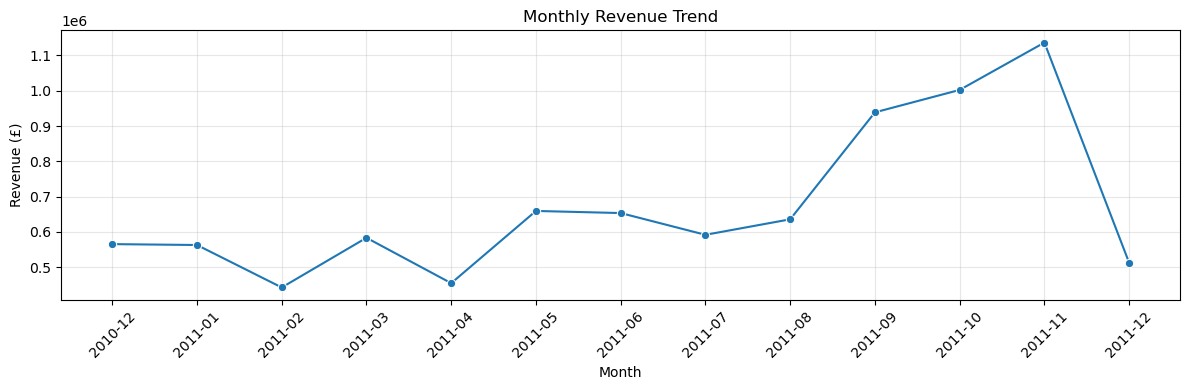

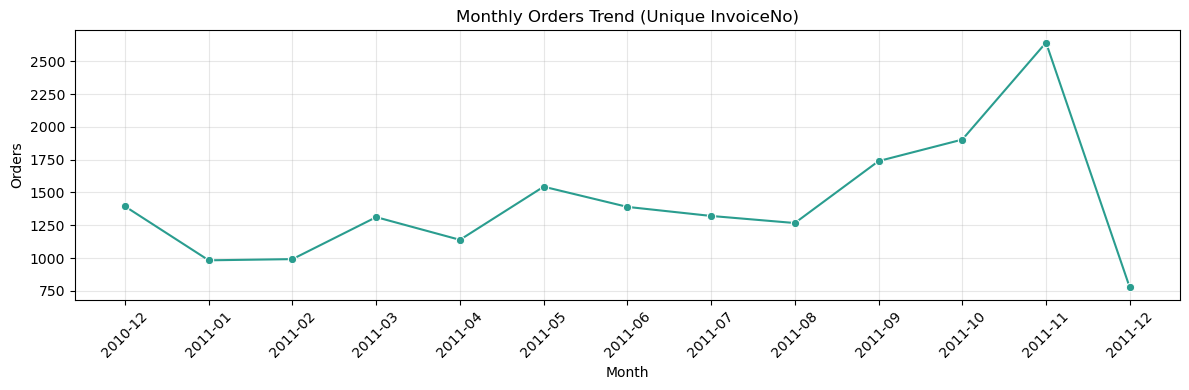

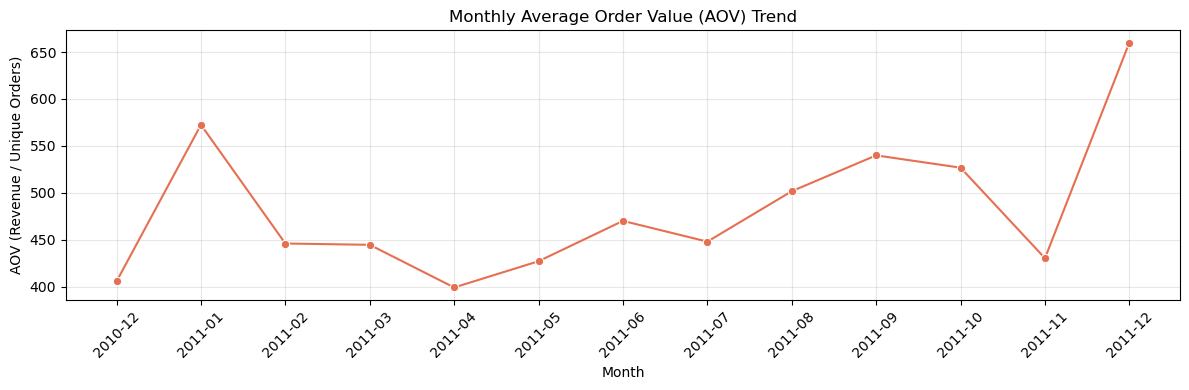

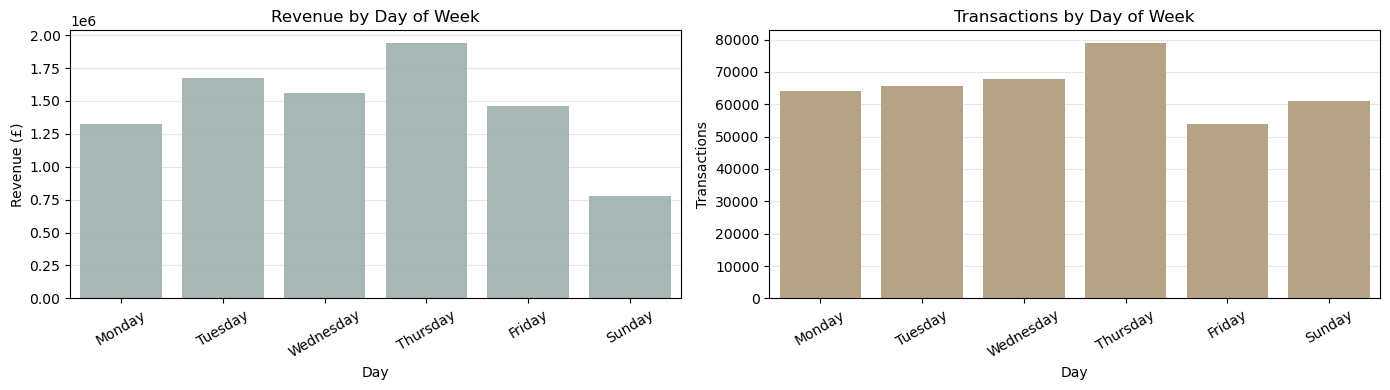

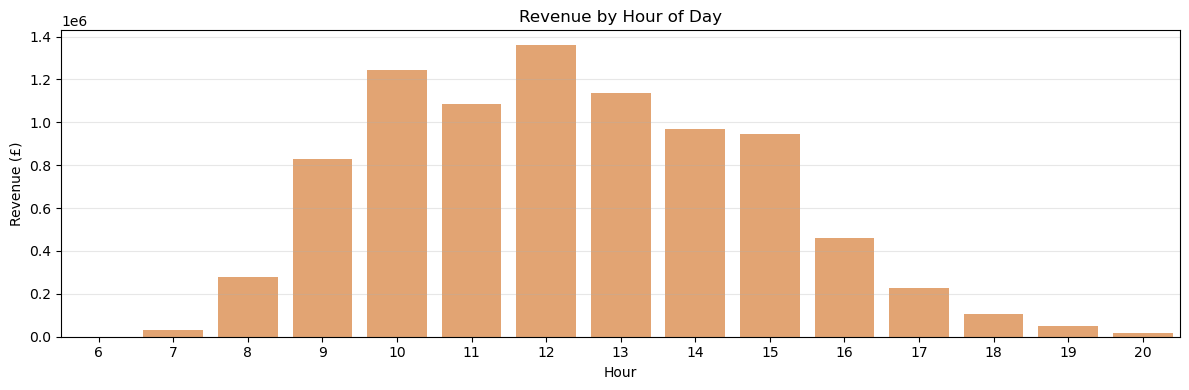

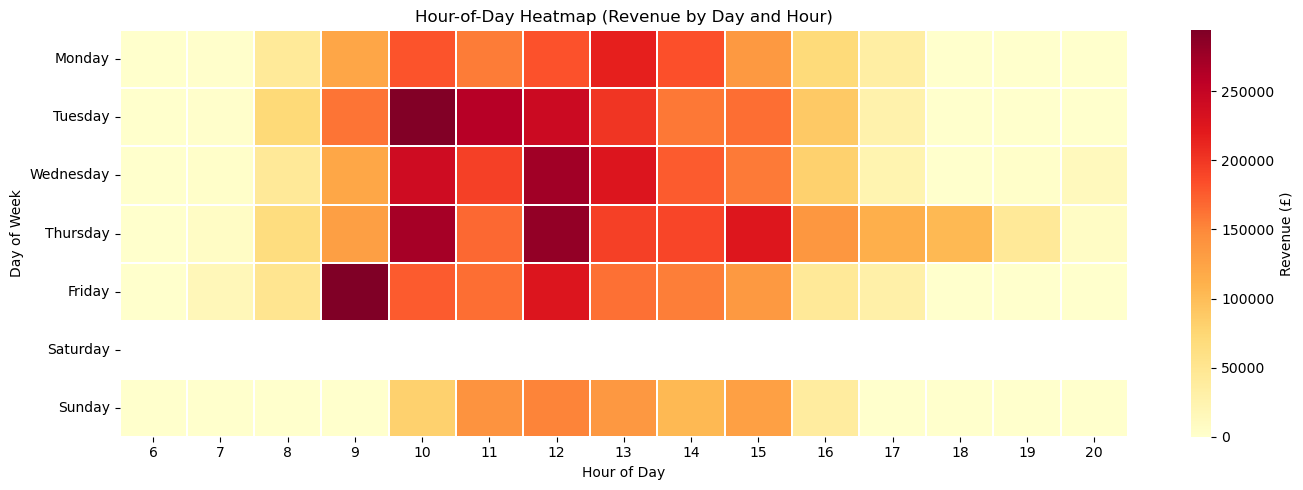

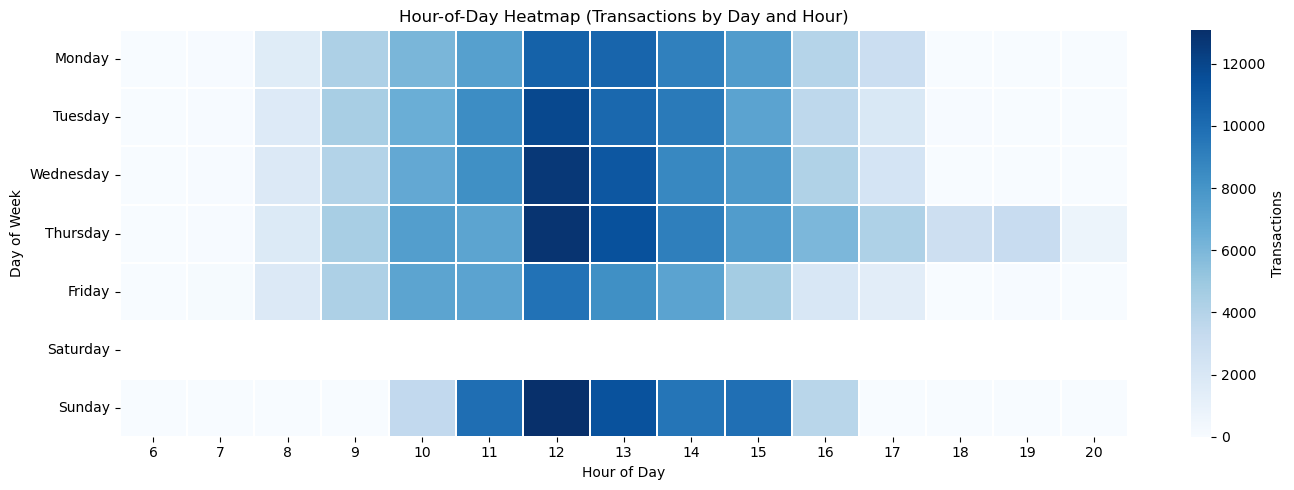


Time-based analysis complete


In [84]:
revenue_by_month = df_clean.groupby(df_clean['InvoiceDate'].dt.to_period('M')).agg(
    Revenue=('TotalAmount', 'sum'),
    Orders=('InvoiceNo', 'nunique'),
    LineItems=('InvoiceNo', 'count')
)

revenue_by_month['AOV'] = revenue_by_month['Revenue'] / revenue_by_month['Orders']

print("\nRevenue (£) by Month (Top 5):")
print(revenue_by_month.sort_values('Revenue', ascending=False).head())

print("-" * 70)

# Transactions by day of week (0=Monday, 6=Sunday)
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
tx_by_dow = df_clean.groupby('DayOfWeek').agg({'TotalAmount': 'sum', 'InvoiceNo': 'count'})
tx_by_dow.index = [days[i] for i in tx_by_dow.index]
tx_by_dow.columns = ['Revenue', 'Transactions']

print("Transactions by Day of Week:")
print(tx_by_dow)

print("-" * 70)

tx_by_hour = df_clean.groupby('Hour')['TotalAmount'].agg(['sum', 'count'])
top_hours = tx_by_hour.nlargest(5, 'sum')

print("Top 5 Peak Hours by Revenue (£):")
print(top_hours)


monthly_plot = revenue_by_month.copy()
monthly_plot.index = monthly_plot.index.astype(str)

plt.figure(figsize=(12, 4))
sns.lineplot(x=monthly_plot.index, y=monthly_plot['Revenue'], marker='o', color='#1f77b4')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
sns.lineplot(x=monthly_plot.index, y=monthly_plot['Orders'], marker='o', color='#2a9d8f')
plt.title('Monthly Orders Trend (Unique InvoiceNo)')
plt.xlabel('Month')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
sns.lineplot(x=monthly_plot.index, y=monthly_plot['AOV'], marker='o', color='#e76f51')
plt.title('Monthly Average Order Value (AOV) Trend')
plt.xlabel('Month')
plt.ylabel('AOV (Revenue / Unique Orders)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x=tx_by_dow.index, y=tx_by_dow['Revenue'].values, ax=axes[0], color='#A4BAB7')
axes[0].set_title('Revenue by Day of Week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

sns.barplot(x=tx_by_dow.index, y=tx_by_dow['Transactions'].values, ax=axes[1], color='#BEA57D')
axes[1].set_title('Transactions by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Transactions')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

plt.figure(figsize=(12, 4))
sns.barplot(x=tx_by_hour.index, y=tx_by_hour['sum'].values, color='#f4a261')
plt.title('Revenue by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Revenue (£)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

heatmap_data = df_clean.pivot_table(
    index='DayOfWeek',
    columns='Hour',
    values='TotalAmount',
    aggfunc='sum',
    fill_value=0
)
heatmap_data = heatmap_data.reindex([0, 1, 2, 3, 4, 5, 6])
heatmap_data.index = days

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3, cbar_kws={'label': 'Revenue (£)'})
plt.title('Hour-of-Day Heatmap (Revenue by Day and Hour)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

heatmap_tx = df_clean.pivot_table(
    index='DayOfWeek',
    columns='Hour',
    values='InvoiceNo',
    aggfunc='count',
    fill_value=0

)
heatmap_tx = heatmap_tx.reindex([0, 1, 2, 3, 4, 5, 6])
heatmap_tx.index = days

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_tx, cmap='Blues', linewidths=0.3, cbar_kws={'label': 'Transactions'})
plt.title('Hour-of-Day Heatmap (Transactions by Day and Hour)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

print(f"\nTime-based analysis complete")

**Product Analysis**


Top 10 Products by Revenue:
             Revenue  QuantitySold  Transactions
StockCode                                       
23843      168469.60         80995             1
22423      142264.75         12374          1713
85123A     100547.45         36763          2023
85099B      85040.54         46078          1615
23166       81416.73         77916           198
47566       68785.23         15279          1389
84879       56413.03         35263          1395
23084       51251.24         27153           823
22502       47348.35          1485           236
79321       46265.11          9646           521


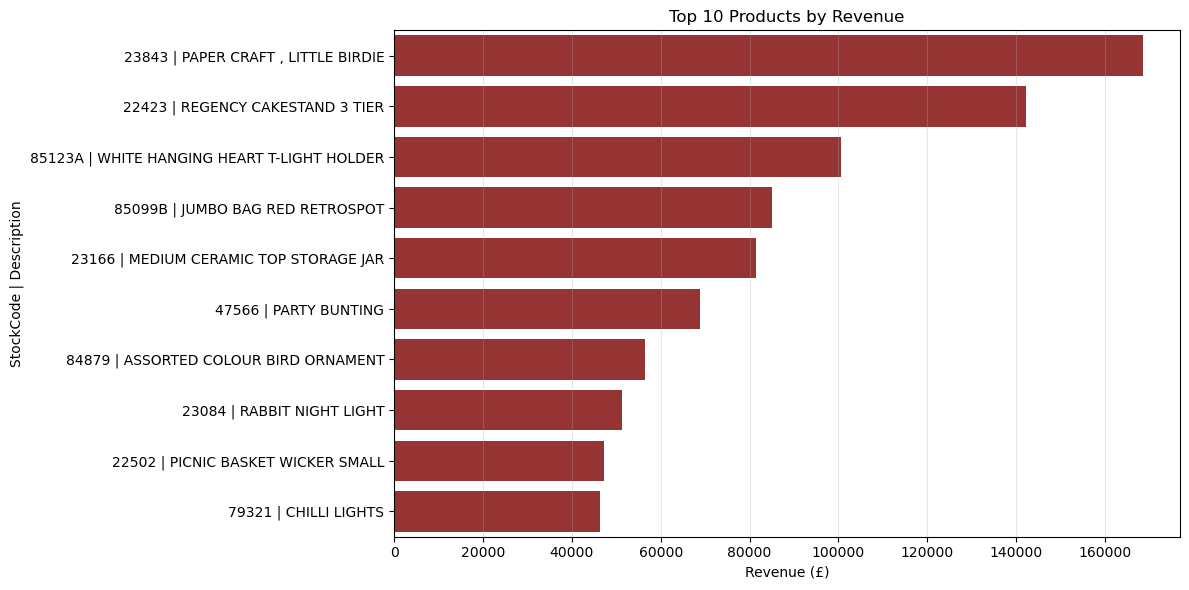


Product analysis complete


In [82]:
product_revenue = df_clean.groupby('StockCode').agg({
    'TotalAmount': 'sum',
    'Quantity': 'sum',
    'InvoiceNo': 'count',
    'Description': 'first'
}).sort_values('TotalAmount', ascending=False)
product_revenue.columns = ['Revenue', 'QuantitySold', 'Transactions', 'Description']

print("\nTop 10 Products by Revenue:")
print(product_revenue[['Revenue', 'QuantitySold', 'Transactions']].head(10))


top_products_plot = product_revenue[['Revenue', 'Description']].head(10).copy()
top_products_plot['Label'] = (
    top_products_plot.index.astype(str) + ' | ' + top_products_plot['Description'].astype(str).str.slice(0, 45)
 )
top_products_plot = top_products_plot.sort_values('Revenue', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products_plot, x='Revenue', y='Label', color='#A52422')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.ylabel('StockCode | Description')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nProduct analysis complete")

**Geographic Analysis**

Top 10 Countries by Revenue (with per-customer value):
                   Revenue  Orders  Customers  RevenuePerCustomer  \
Country                                                             
United Kingdom  7242855.32   16579       3916             1849.55   
Netherlands      283889.34      93          9            31543.26   
EIRE             257013.12     256          3            85671.04   
Germany          205381.15     443         94             2184.91   
France           183801.94     379         87             2112.67   
Australia        138103.81      56          9            15344.87   
Spain             55706.56      88         30             1856.89   
Switzerland       52441.95      47         21             2497.24   
Japan             37416.37      19          8             4677.05   
Belgium           36927.34      98         25             1477.09   

                OrdersPerCustomer  AvgOrderValue  
Country                                           
United Kingdom

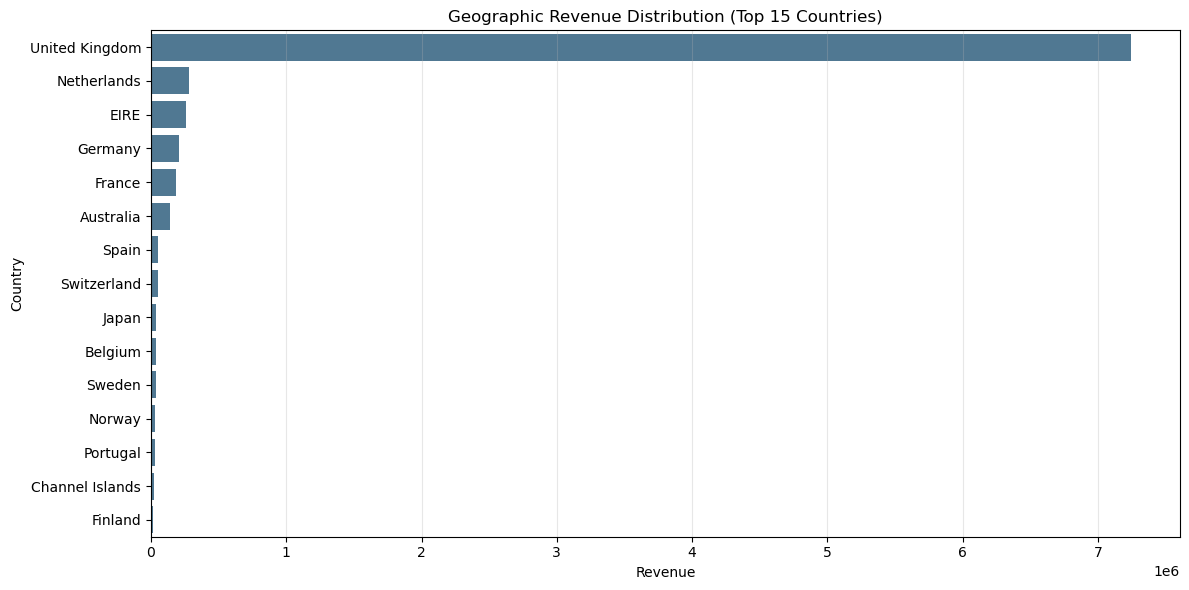

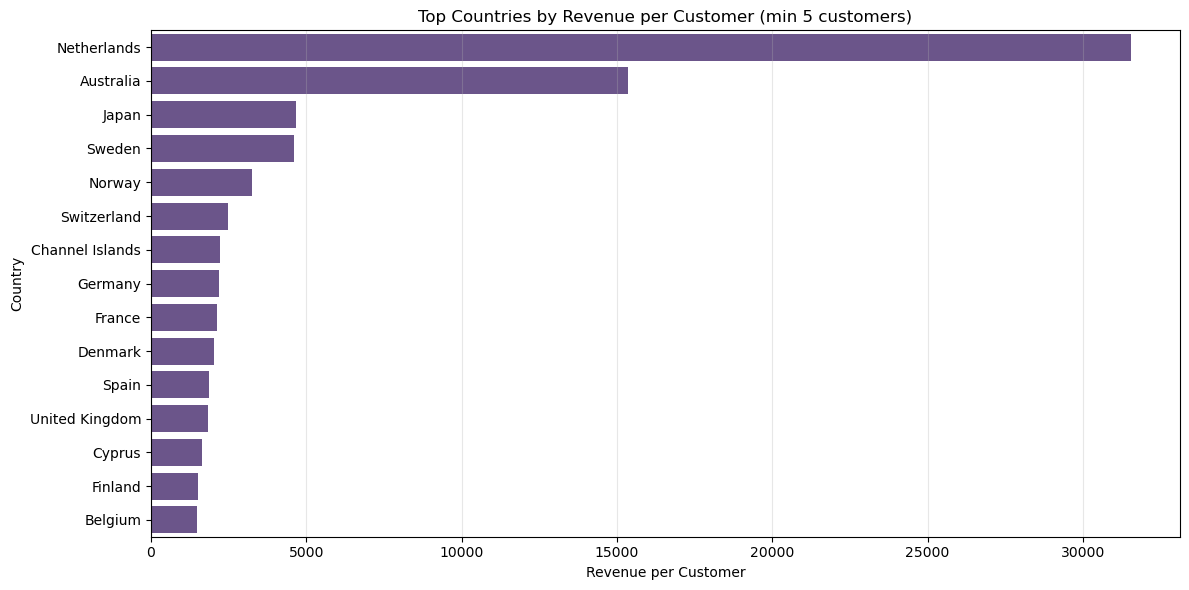


Geographic analysis complete


In [87]:
country_revenue = df_clean.groupby('Country').agg(
    Revenue=('TotalAmount', 'sum'),
    Orders=('InvoiceNo', 'nunique'),
    Customers=('CustomerID', 'nunique'),
    LineItems=('InvoiceNo', 'count')
).sort_values('Revenue', ascending=False)
country_revenue['RevenuePerCustomer'] = country_revenue['Revenue'] / country_revenue['Customers']
country_revenue['OrdersPerCustomer'] = country_revenue['Orders'] / country_revenue['Customers']
country_revenue['AvgOrderValue'] = country_revenue['Revenue'] / country_revenue['Orders']

print("Top 10 Countries by Revenue (with per-customer value):")
print(
    country_revenue[
        ['Revenue', 'Orders', 'Customers', 'RevenuePerCustomer', 'OrdersPerCustomer', 'AvgOrderValue']
    ].head(10).round(2)
)

print("-" * 70)

print("\nTop 10 Countries by Revenue per Customer (min 5 customers):")
high_value_geo = country_revenue[country_revenue['Customers'] >= 5].sort_values('RevenuePerCustomer', ascending=False)
print(
    high_value_geo[
        ['Revenue', 'Orders', 'Customers', 'RevenuePerCustomer', 'OrdersPerCustomer', 'AvgOrderValue']
    ].head(10).round(2)
)

print("-" * 70)

geo_plot = country_revenue.head(15).sort_values('Revenue', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=geo_plot, x='Revenue', y=geo_plot.index, color='#457b9d')
plt.title('Geographic Revenue Distribution (Top 15 Countries)')
plt.xlabel('Revenue')
plt.ylabel('Country')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

rvpc_plot = high_value_geo.head(15).sort_values('RevenuePerCustomer', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=rvpc_plot, x='RevenuePerCustomer', y=rvpc_plot.index, color='#6a4c93')
plt.title('Top Countries by Revenue per Customer (min 5 customers)')
plt.xlabel('Revenue per Customer')
plt.ylabel('Country')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nGeographic analysis complete")